In [64]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import GradientBoostingRegressor
import xgboost as xgb
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import make_scorer
from xgboost import XGBRegressor

In [65]:
df=pd.read_csv('train.csv')
test=pd.read_csv('test.csv')

In [66]:

df.head()

,id,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty,exam_score
0,0,21,female,b.sc,7.91,98.8,no,4.9,average,online videos,low,easy,78.3
1,1,18,other,diploma,4.95,94.8,yes,4.7,poor,self-study,medium,moderate,46.7
2,2,20,female,b.sc,4.68,92.6,yes,5.8,poor,coaching,high,moderate,99.0
3,3,19,male,b.sc,2.00,49.5,yes,8.3,average,group study,high,moderate,63.9
4,4,23,male,bca,7.65,86.9,yes,9.6,good,self-study,high,easy,100.0


In [67]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 630000 entries, 0 to 629999
Data columns (total 13 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   id                630000 non-null  int64  
 1   age               630000 non-null  int64  
 2   gender            630000 non-null  object 
 3   course            630000 non-null  object 
 4   study_hours       630000 non-null  float64
 5   class_attendance  630000 non-null  float64
 6   internet_access   630000 non-null  object 
 7   sleep_hours       630000 non-null  float64
 8   sleep_quality     630000 non-null  object 
 9   study_method      630000 non-null  object 
 10  facility_rating   630000 non-null  object 
 11  exam_difficulty   630000 non-null  object 
 12  exam_score        630000 non-null  float64
dtypes: float64(4), int64(2), object(7)
memory usage: 62.5+ MB


In [68]:
print(df.shape)
print(df.isnull().sum())
print(df.duplicated().sum())

(630000, 13)
id                  0
age                 0
gender              0
course              0
study_hours         0
class_attendance    0
internet_access     0
sleep_hours         0
sleep_quality       0
study_method        0
facility_rating     0
exam_difficulty     0
exam_score          0
dtype: int64
0


In [69]:
l=['course','gender','facility_rating','study_method','exam_difficulty','sleep_quality','internet_access']
for i in l:
    print(df[i].value_counts())

course
b.tech     131236
b.sc       111554
b.com      110932
bca         88721
bba         75644
ba          61989
diploma     49924
Name: count, dtype: int64
gender
other     211097
male      210593
female    208310
Name: count, dtype: int64
facility_rating
medium    214082
low       212378
high      203540
Name: count, dtype: int64
study_method
coaching         131697
self-study       131131
mixed            123086
group study      123009
online videos    121077
Name: count, dtype: int64
exam_difficulty
moderate    353982
easy        176540
hard         99478
Name: count, dtype: int64
sleep_quality
poor       213675
good       213089
average    203236
Name: count, dtype: int64
internet_access
yes    579423
no      50577
Name: count, dtype: int64


In [70]:
df.describe()

,id,age,study_hours,class_attendance,sleep_hours,exam_score
count,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000
mean,314999.500000,20.545821,4.002337,71.987261,7.072758,62.506672
std,181865.479132,2.260238,2.359880,17.430098,1.744811,18.916884
min,0.000000,17.000000,0.080000,40.600000,4.100000,19.599000
25%,157499.750000,19.000000,1.970000,57.000000,5.600000,48.800000
50%,314999.500000,21.000000,4.000000,72.600000,7.100000,62.600000
75%,472499.250000,23.000000,6.050000,87.200000,8.600000,76.300000
max,629999.000000,24.000000,7.910000,99.400000,9.900000,100.000000


In [71]:

df = df.drop(columns=['id'])

In [72]:
df['course'] = df['course'].str.lower().str.strip()
df['study_method'] = df['study_method'].str.lower().str.strip()

In [73]:
num_cols = df.select_dtypes(include=['int64','float64']).columns
cat_cols = df.select_dtypes(include=['object']).columns

df[num_cols] = df[num_cols].fillna(df[num_cols].median())
df[cat_cols] = df[cat_cols].fillna(df[cat_cols].mode().iloc[0])
df = df.drop_duplicates()

<Axes: xlabel='age', ylabel='Count'>

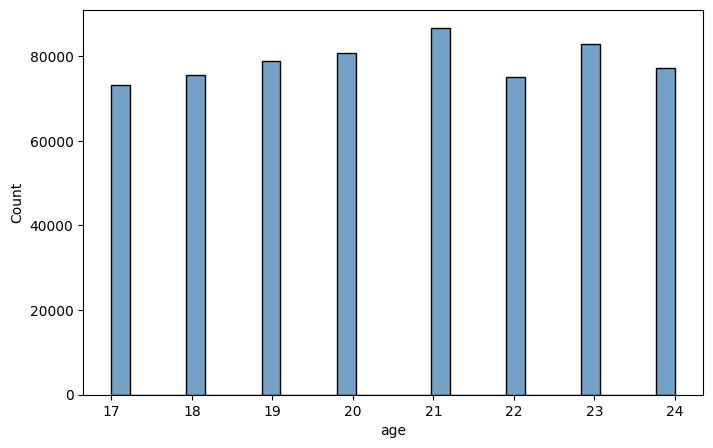

In [74]:
#visualisation

col = 'age'
plt.figure(figsize=(8, 5))
sns.histplot(df[col], bins=30, color='steelblue', kde=False, edgecolor='black')

<Axes: xlabel='study_hours', ylabel='Count'>

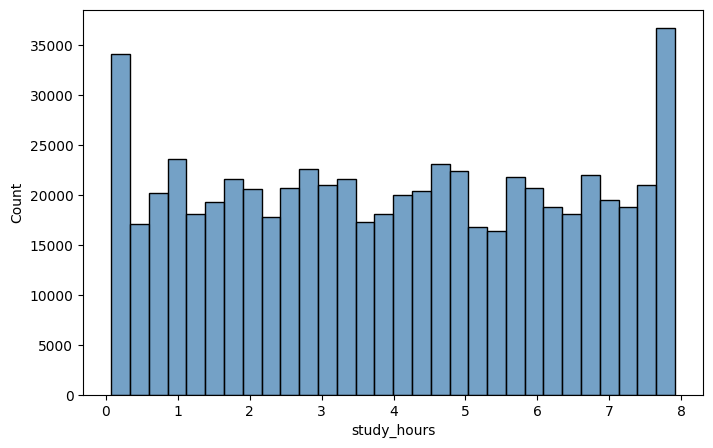

In [75]:
col = 'study_hours'
plt.figure(figsize=(8, 5))
sns.histplot(df[col], bins=30, color='steelblue', kde=False, edgecolor='black')

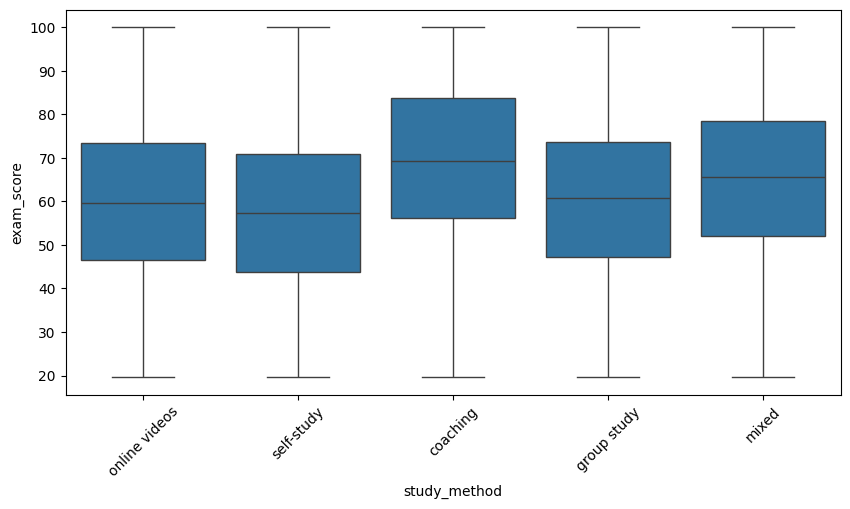

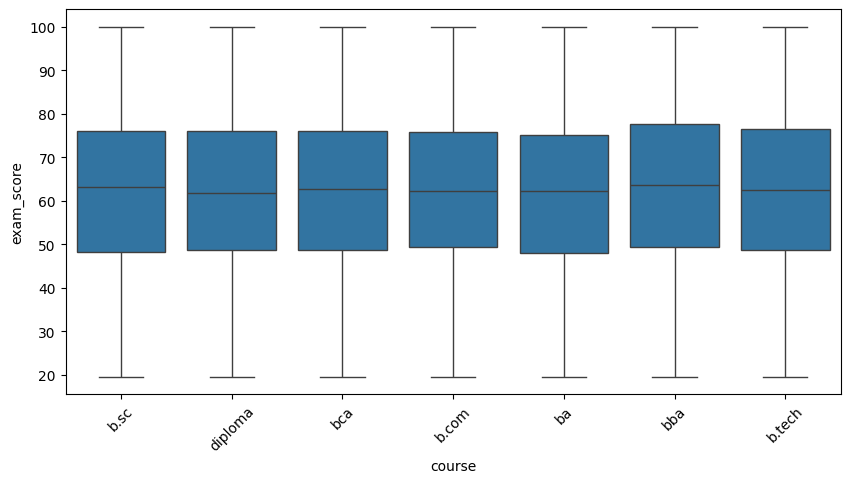

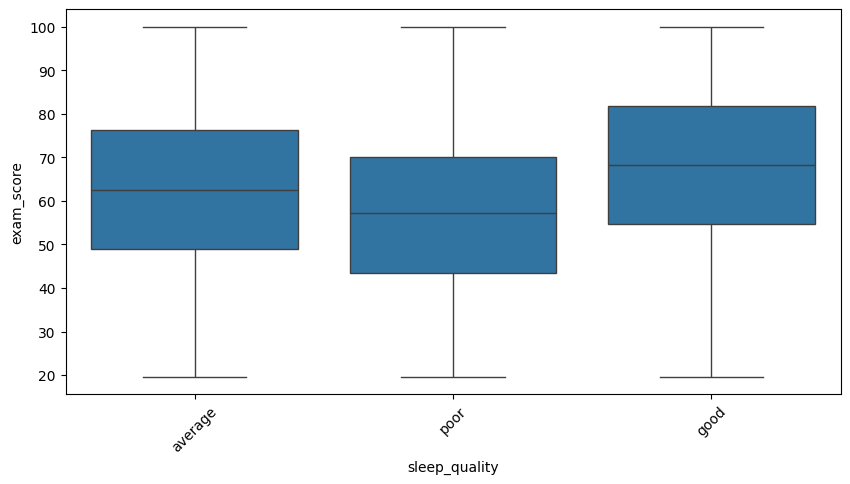

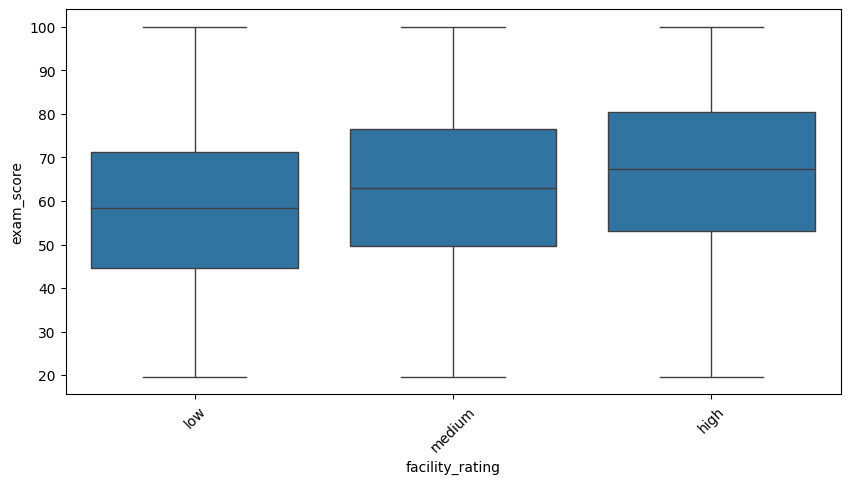

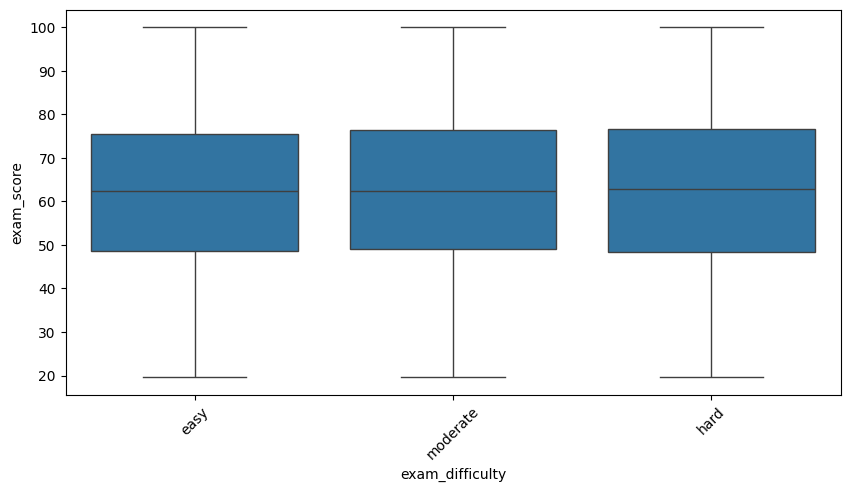

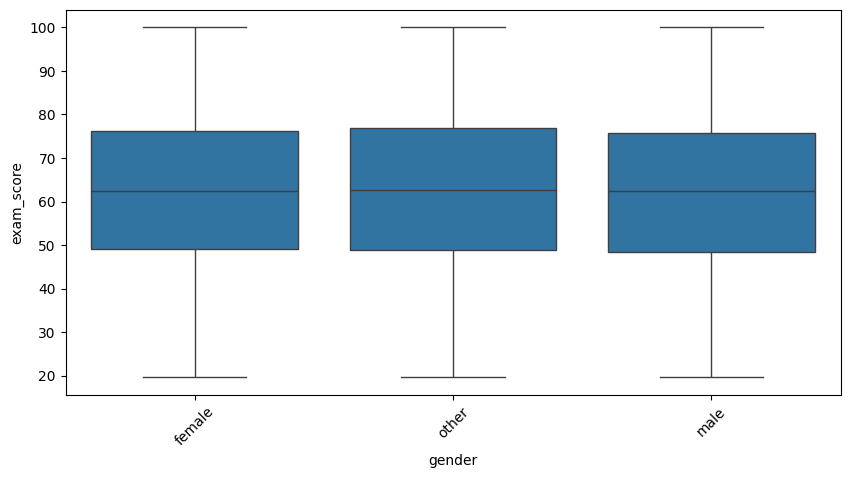

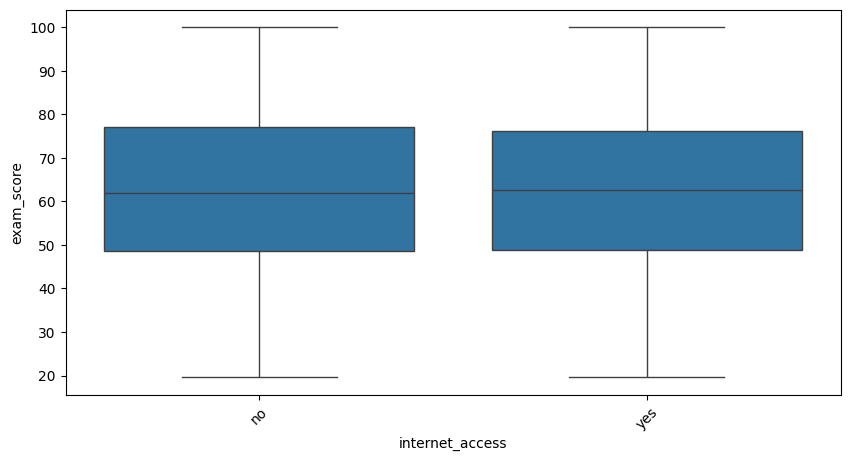

In [76]:
import seaborn as sns
import matplotlib.pyplot as plt
l=['study_method','course','sleep_quality','facility_rating',
'exam_difficulty','gender','internet_access']
for col in l:
  plt.figure(figsize=(10,5))
  sns.boxplot(x=col, y='exam_score', data=df)
  plt.xticks(rotation=45)
  plt.show()

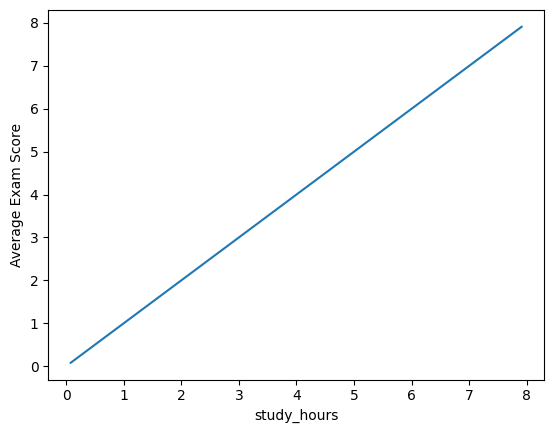

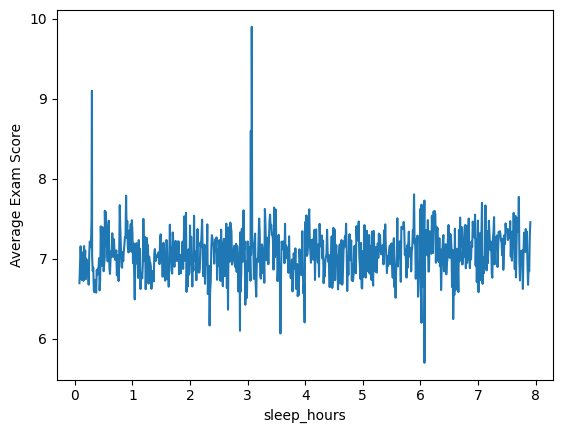

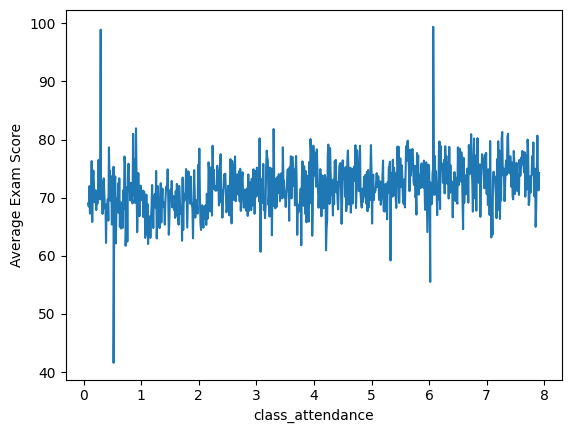

In [77]:
l=['study_hours','sleep_hours','class_attendance']
for col in l:
  grouped = df.groupby('study_hours')[col].mean()
  grouped.plot()
  plt.xlabel(col)
  plt.ylabel('Average Exam Score')
  plt.show()

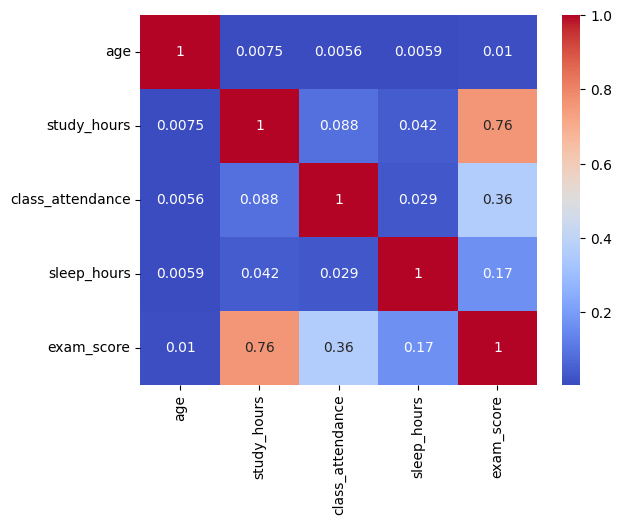

In [78]:
corr = df[['age','study_hours','class_attendance','sleep_hours','exam_score']].corr()

sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()

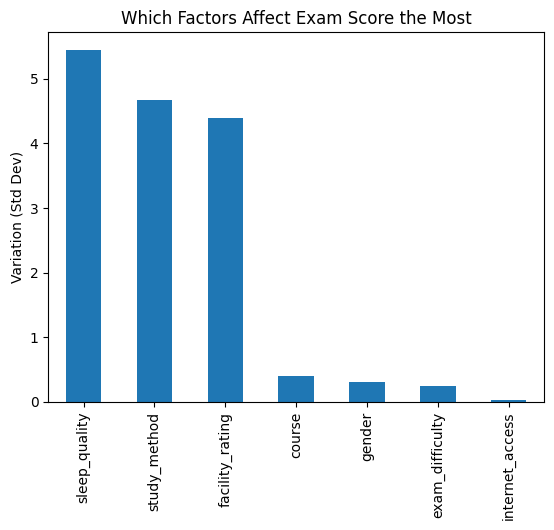

In [79]:
categorical_cols = df.select_dtypes(include=['object']).columns

importance = {}

for col in categorical_cols:
    importance[col] = df.groupby(col)['exam_score'].mean().std()

importance = pd.Series(importance).sort_values(ascending=False)

importance.plot(kind='bar')
plt.title("Which Factors Affect Exam Score the Most")
plt.ylabel("Variation (Std Dev)")
plt.show()

In [80]:
# Check invalid values
print("Invalid age:", df[(df['age'] < 10) | (df['age'] > 60)].shape[0])
print("Invalid study_hours:", df[(df['study_hours'] < 0) | (df['study_hours'] > 24)].shape[0])
print("Invalid sleep_hours:", df[(df['sleep_hours'] < 0) | (df['sleep_hours'] > 24)].shape[0])
print("Invalid attendance:", df[(df['class_attendance'] < 0) | (df['class_attendance'] > 100)].shape[0])
print("Invalid score:", df[(df['exam_score'] < 0) | (df['exam_score'] > 100)].shape[0])

Invalid age: 0
Invalid study_hours: 0
Invalid sleep_hours: 0
Invalid attendance: 0
Invalid score: 0


In [81]:


df['sleep_quality'] = df['sleep_quality'].map({
    'poor': 0,
    'average': 1,
    'good': 2
})

df['facility_rating'] = df['facility_rating'].map({
    'low': 0,
    'medium': 1,
    'high': 2
})

df['exam_difficulty'] = df['exam_difficulty'].map({
    'easy': 0,
    'moderate': 1,
    'hard': 2
})

df['internet_access'] = df['internet_access'].map({
    'no': 0,
    'yes': 1
})


In [82]:
df['effort_score'] = df['study_hours'] * df['class_attendance']
df['sleep_impact'] = df['sleep_hours'] * df['sleep_quality']
df['stress_level'] = df['exam_difficulty'] * df['study_hours']
df['digital_usage'] = df['internet_access'] * df['study_hours']
df['study_sleep_ratio'] = df['study_hours'] / (df['sleep_hours'] + 1)
df['attendance_sleep'] = df['class_attendance'] * df['sleep_quality']
df['sleep_balance'] = df['sleep_hours'] * (df['sleep_quality'] == 2).astype(int)
df['age_group'] = pd.cut(df['age'], bins=[0,18,25,40,100], labels=[0,1,2,3])
df['attendance_level'] = pd.cut(df['class_attendance'], bins=[0,60,80,100], labels=[0,1,2])


In [83]:
df = df[
    (df['age'].between(10, 60)) &
    (df['study_hours'].between(0, 24)) &
    (df['sleep_hours'].between(0, 24)) &
    (df['class_attendance'].between(0, 100)) &
    (df['exam_score'].between(0, 100))
]

In [84]:
for col in ['age','study_hours']:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df[col] = np.clip(df[col], lower, upper)


In [85]:
df = pd.get_dummies(df, drop_first=True)

In [86]:


X = df.drop(columns=['exam_score'])
y = df['exam_score']

In [87]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [88]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [89]:
models = {
    "Linear Regression": LinearRegression(),
    "Gradient Boosting": GradientBoostingRegressor(),
    "xgb":XGBRegressor(n_estimators=200, learning_rate=0.05)
}

In [90]:
from sklearn.metrics import r2_score, mean_absolute_error ,mean_squared_error

results = []

for name, model in models.items():

    # Train
    model.fit(X_train, y_train)

    # Predict
    y_pred = model.predict(X_test)

    # Evaluate
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    results.append({
        "Model": name,
        "R2 Score": r2,
        "MAE": mae,
        "RMSE": rmse
    })

In [91]:
results_df = pd.DataFrame(results)

# Sort by RMSE (LOWER is better)
results_df = results_df.sort_values(by="RMSE")

results_df

,Model,R2 Score,MAE,RMSE
2,xgb,0.781848,7.031366,8.808252
0,Linear Regression,0.778017,7.092201,8.885248
1,Gradient Boosting,0.777044,7.128138,8.904694


In [92]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=300,
    learning_rate=0.03,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

In [93]:
xgb.fit(X_train,y_train)


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.03, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=300,
             n_jobs=None, num_parallel_tree=None, ...)

In [94]:
# Predict
y_pred = xgb.predict(X_test)

    # Evaluate
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

In [95]:
print("R2 Score:", r2)
print("MAE:", mae)
print("RMSE:", rmse)

R2 Score: 0.7819105899953395
MAE: 7.030640487771413
RMSE: 8.806978956359975


In [96]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import make_scorer, mean_squared_error
xgb = XGBRegressor(random_state=42)
param_dist = {
    "n_estimators": [100, 200, 300, 500],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "max_depth": [3, 4, 5, 6, 8],
    "subsample": [0.6, 0.8, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0],
    "gamma": [0, 0.1, 0.2, 0.3],
    "reg_alpha": [0, 0.1, 1],
    "reg_lambda": [1, 1.5, 2]
}
rmse_scorer = make_scorer(
    mean_squared_error,
    squared=False  # gives RMSE directly
)
random_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_dist,
    n_iter=20,              # increase to 50+ if you want better results
    scoring=rmse_scorer,
    cv=3,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

Fitting 3 folds for each of 20 candidates, totalling 60 fits


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:1108: UserWarning: One or more of the test scores are non-finite: [nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan]
  warnings.warn(


RandomizedSearchCV(cv=3,
                   estimator=XGBRegressor(base_score=None, booster=None,
                                          callbacks=None,
                                          colsample_bylevel=None,
                                          colsample_bynode=None,
                                          colsample_bytree=None, device=None,
                                          early_stopping_rounds=None,
                                          enable_categorical=False,
                                          eval_metric=None, feature_types=None,
                                          feature_weights=None, gamma=None,
                                          grow_policy=None,
                                          importance_type=None,
                                          interaction_constraint...
                   param_distributions={'colsample_bytree': [0.6, 0.8, 1.0],
                                        'gamma': [0, 0.1, 0.2, 0.3],
                                        'learning_rate': [0.01, 0.03, 0.05,
                                                          0.1],
                                        'max_depth': [3, 4, 5, 6, 8],
                                        'n_estimators': [100, 200, 300, 500],
                                        'reg_alpha': [0, 0.1, 1],
                                        'reg_lambda': [1, 1.5, 2],
                                        'subsample': [0.6, 0.8, 1.0]},
                   random_state=42,
                   scoring=make_scorer(mean_squared_error, response_method='predict', squared=False),
                   verbose=2)

In [97]:
print("Best Params:", random_search.best_params_)

Best Params: {'subsample': 1.0, 'reg_lambda': 1, 'reg_alpha': 0, 'n_estimators': 100, 'max_depth': 8, 'learning_rate': 0.1, 'gamma': 0.2, 'colsample_bytree': 1.0}


In [98]:
best_xgb = random_search.best_estimator_

y_pred = best_xgb.predict(X_test)

from sklearn.metrics import r2_score

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("RMSE:", rmse)
print("R2:", r2)

RMSE: 8.797376880014102
R2: 0.7823858879587627


In [99]:
#test

In [100]:
test = pd.read_csv("test.csv")

test_ids = test['id']

# Apply same cleaning
test['course'] = test['course'].str.lower().str.strip()
test['study_method'] = test['study_method'].str.lower().str.strip()

# Same encoding
test['sleep_quality'] = test['sleep_quality'].map({'poor':0,'average':1,'good':2})
test['facility_rating'] = test['facility_rating'].map({'low':0,'medium':1,'high':2})
test['exam_difficulty'] = test['exam_difficulty'].map({'easy':0,'moderate':1,'hard':2})
test['internet_access'] = test['internet_access'].map({'no':0,'yes':1})

# SAME feature engineering
test['effort_score'] = test['study_hours'] * test['class_attendance']
test['sleep_impact'] = test['sleep_hours'] * test['sleep_quality']
test['stress_level'] = test['exam_difficulty'] * test['study_hours']
test['digital_usage'] = test['internet_access'] * test['study_hours']
test['study_sleep_ratio'] = test['study_hours'] / (test['sleep_hours'] + 1)
test['attendance_sleep'] = test['class_attendance'] * test['sleep_quality']
test['sleep_balance'] = test['sleep_hours'] * (test['sleep_quality'] == 2).astype(int)
test['age_group'] = pd.cut(test['age'], bins=[0,18,25,40,100], labels=[0,1,2,3])
test['attendance_level'] = pd.cut(test['class_attendance'], bins=[0,60,80,100], labels=[0,1,2])

# One-hot encoding
test = pd.get_dummies(test, drop_first=True)

# Align columns
test = test.reindex(columns=X.columns, fill_value=0)

# Scale
test = scaler.transform(test)





In [101]:

predictions = best_xgb.predict(test)

submission = pd.DataFrame({
    'id': test_ids,
    'exam_score': predictions
})

submission.to_csv("submission.csv", index=False)

print("✅ Submission file created!")

✅ Submission file created!
